# 🌳 Decision Tree — Iris Dataset


In [11]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

## 1️⃣ تحميل الداتا

In [12]:
iris = load_iris()

# iris.data  → الـ features (طول وعرض البتلة والسبلة)
# iris.target → الـ labels  (0=setosa / 1=versicolor / 2=virginica)
X = iris.data
y = iris.target

print('شكل الداتا  :', X.shape)          # (150 صف, 4 features)
print('الـ Features :', iris.feature_names)
print('الـ Classes  :', iris.target_names)

شكل الداتا  : (150, 4)
الـ Features : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
الـ Classes  : ['setosa' 'versicolor' 'virginica']


## 2️⃣ تقسيم الداتا

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,   # 25% للاختبار، 75% للتدريب
    random_state=42,  # عشان النتايج تبقى ثابتة كل ما تشغّل

    # ============================================================
    # 🔍 stratify=y  — ايه معناها؟
    # ============================================================
    # بدونها: الـ split ممكن يبقى عشوائي ويحط كل الـ setosa
    #         في الـ training مثلاً، والموديل مش هيتعلم عليها كويس
    #
    # معاها: بتضمن إن نسبة كل class في الـ train
    #         تبقى نفس نسبتها في الـ test
    #
    # مثال: لو عندنا 50 setosa, 50 versicolor, 50 virginica
    # بدون stratify → الـ test ممكن يبقى فيه 30 setosa و5 versicolor!
    # مع stratify=y → الـ test هيبقى فيه ~12 من كل class بالظبط ✅
    # ============================================================
    stratify=y
)

print('Train size:', X_train.shape)   # 112 صف
print('Test size :', X_test.shape)    # 38  صف

Train size: (112, 4)
Test size : (38, 4)


## 3️⃣ بناء الـ Decision Tree

In [14]:
dt_model = DecisionTreeClassifier(

    # ============================================================
    # criterion='entropy'
    # ============================================================
    # ده اللي بيقول للشجرة: بأي معيار تختار أحسن سؤال تسأله؟
    # 'entropy' → بتستخدم Information Gain
    # 'gini'    → بتستخدم Gini Impurity (الـ default)
    # الفرق مشروح بالتفصيل في الـ cell الجاي
    # ============================================================
    criterion='entropy',

    # ============================================================
    # max_depth=3
    # ============================================================
    # بتحدد أقصى عمق للشجرة (كام سؤال تسأل)
    # لو مقولتهاش → هتكبر لحد ما تحفظ كل الداتا (Overfitting)
    # max_depth=3 → 3 أسئلة بس وبعدين توقف ✅
    # ============================================================
    max_depth=3,

    random_state=42  # ثبّت النتايج
)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## 4️⃣ التقييم

In [15]:
dt_pred = dt_model.predict(X_test)

print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=iris.target_names
))

# قراءة التقرير:
# precision → من اللي قلت إنه X، كام واحد فعلاً X؟
# recall    → من اللي هو فعلاً X، كام واحد اكتشفته؟
# f1-score  → المتوسط الموزون بين precision و recall

Decision Tree Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.80      0.92      0.86        13
   virginica       0.91      0.77      0.83        13

    accuracy                           0.89        38
   macro avg       0.90      0.90      0.90        38
weighted avg       0.90      0.89      0.89        38



## 5️⃣ رسم الشجرة

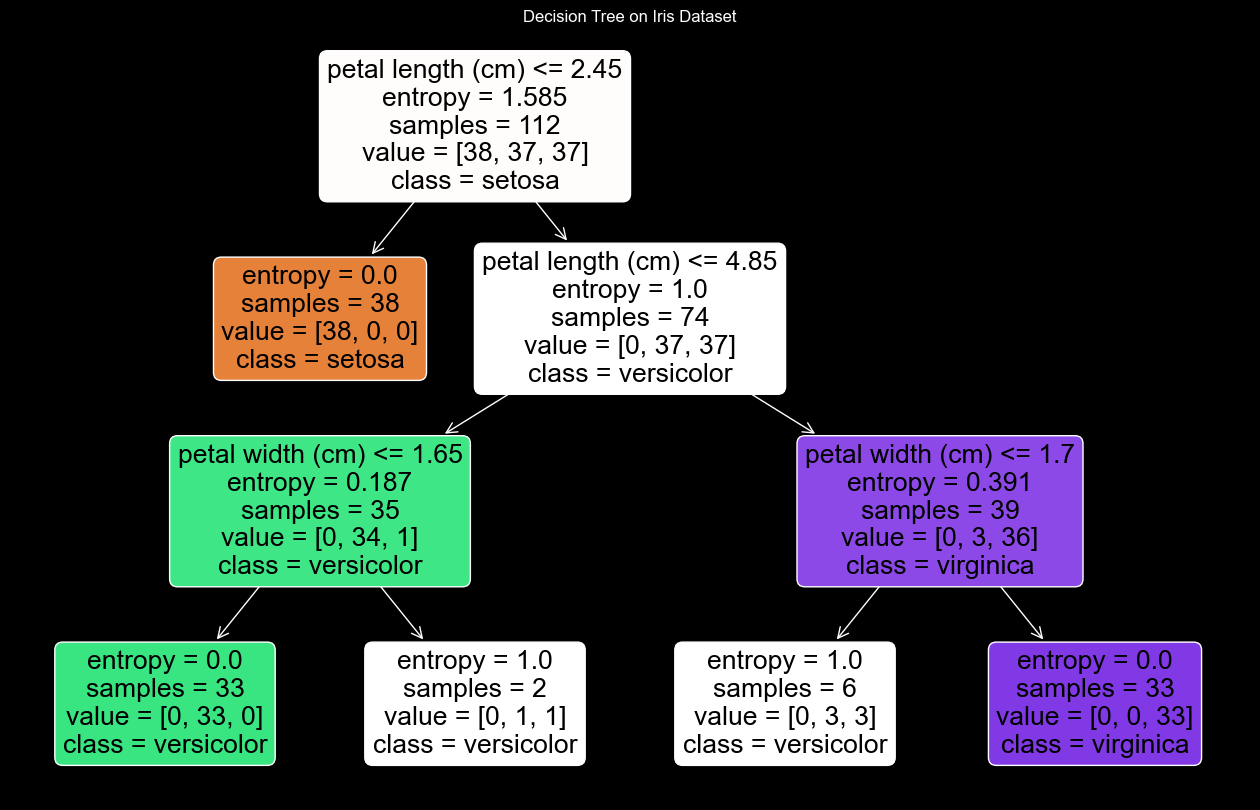

In [16]:
plt.figure(figsize=(16, 10))

texts = plot_tree(
    dt_model,
    feature_names=iris.feature_names,  # أسامي الـ features في كل node
    class_names=iris.target_names,     # أسامي الـ classes في الـ leaf nodes
    filled=True,                       # لون كل node بلون الـ class الأغلب فيها
    rounded=True                       # زوايا دايرية للـ nodes
)

for text in texts:
    text.set_color("black")  # بيخلي الكتابة سودة عشان تتقرأ

plt.title("Decision Tree on Iris Dataset")
plt.show()

# قراءة كل node في الشجرة:
# السطر 1 → السؤال اللي بيتسأل  (مثال: petal length <= 2.45)
# السطر 2 → قيمة الـ entropy أو gini في الـ node دي
# السطر 3 → عدد الـ samples اللي وصلت للـ node دي
# السطر 4 → توزيع الـ samples على الـ classes [setosa, versicolor, virginica]
# السطر 5 → الـ class الأغلب في الـ node دي

---
## 🧮 Gini vs Entropy — المقارنة الكاملة

الاتنين بيجاوبوا على نفس السؤال:

> **"أحسن feature أسأل عنها عشان أقسّم الداتا؟"**

بس كل واحد بيحسب الإجابة بطريقة مختلفة.

---

### 🔵 Gini Impurity

**الفكرة:** لو اخترت sample عشوائي من الـ node، ما هو احتمال إنك تصنّفها غلط؟

$$Gini = 1 - \sum_{i=1}^{k} p_i^2$$

- $p_i$ = نسبة الـ class $i$ في الـ node
- القيمة بين **0** (نقاء كامل) و **0.5** (فوضى كاملة لـ binary)

**مثال:** node فيها 4 samples: 3 setosa و 1 versicolor
$$p_{setosa} = 0.75,\quad p_{versicolor} = 0.25$$
$$Gini = 1 - (0.75^2 + 0.25^2) = 1 - (0.5625 + 0.0625) = 0.375$$

---

### 🔴 Entropy & Information Gain

**الفكرة:** الـ Entropy بتقيس مقدار الـ "فوضى" أو عدم التأكد في الـ node.

$$Entropy = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

- القيمة بين **0** (نقاء كامل) و **1** (فوضى كاملة لـ binary)

**نفس المثال:** 3 setosa و 1 versicolor
$$Entropy = -(0.75 \log_2 0.75 + 0.25 \log_2 0.25)$$
$$= -(0.75 \times -0.415 + 0.25 \times -2) = 0.811$$

**الـ Information Gain** هو اللي الشجرة بتختار بيه الـ feature:
$$IG = Entropy_{parent} - \sum_{children} \frac{n_{child}}{n_{parent}} \times Entropy_{child}$$

الشجرة بتاخد الـ feature اللي عندها **أعلى Information Gain** ✅

---

### ⚖️ جدول المقارنة

| الموضوع | 🔵 Gini | 🔴 Entropy |
|---------|---------|----------|
| **المعادلة** | $1 - \sum p_i^2$ | $-\sum p_i \log_2 p_i$ |
| **نطاق القيمة** | 0 → 0.5 | 0 → 1 |
| **السرعة** | ⚡ أسرع (مفيش log) | 🐢 أبطأ شوية |
| **النتايج** | متشابهين في الغالب | متشابهين في الغالب |
| **بتفضل الـ** | majority classes | balanced splits |
| **الـ default في sklearn** | ✅ أيوه | لا |
| **امتى تستخدمه** | داتا كبيرة أو سرعة مهمة | عايز دقة أعلى في الاختيار |

---

### 🎯 ايه الأفضل؟

**الحقيقة:** في 90% من الحالات النتايج **متشابهة جداً**.

- ✅ استخدم **Gini** لو الداتا كبيرة أو عايز سرعة أكبر — ده الـ default وكافي
- ✅ استخدم **Entropy** لو عايز الشجرة تفكر أكتر في كيفية تقسيم الـ classes بشكل متوازن
- ✅ الأفضل دايماً: **جرّب الاتنين مع GridSearchCV** وشوف مين أحسن على داتاك

In [17]:
import numpy as np

# =====================================================
# مقارنة عملية: Gini vs Entropy على نفس الداتا
# =====================================================

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"criterion={criterion:>8} → Accuracy: {acc:.4f}")

# هتلاقي النتايج متقاربة جداً — ده طبيعي

criterion=    gini → Accuracy: 0.8947
criterion= entropy → Accuracy: 0.8947
